# Домашнее задание №11

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Задание 1

Подготовить тестовое изображение в градациях серого.

In [2]:
h, w = 420, 600
gray = np.full((h, w), 240, dtype=np.uint8)
cv2.rectangle(gray, (40, 40), (230, 190), 70, -1)
cv2.circle(gray, (420, 120), 75, 120, -1)
pts = np.array([[300, 230], [490, 210], [530, 360], [260, 380]], np.int32)
cv2.fillPoly(gray, [pts], 95)
for x in range(40, 220, 20):
    cv2.line(gray, (x, 250), (x + 120, 390), 145, 2)
cv2.putText(gray, 'CV11', (60, 360), cv2.FONT_HERSHEY_SIMPLEX, 1.6, 45, 3)

array([[240, 240, 240, ..., 240, 240, 240],
       [240, 240, 240, ..., 240, 240, 240],
       [240, 240, 240, ..., 240, 240, 240],
       ...,
       [240, 240, 240, ..., 240, 240, 240],
       [240, 240, 240, ..., 240, 240, 240],
       [240, 240, 240, ..., 240, 240, 240]], shape=(420, 600), dtype=uint8)

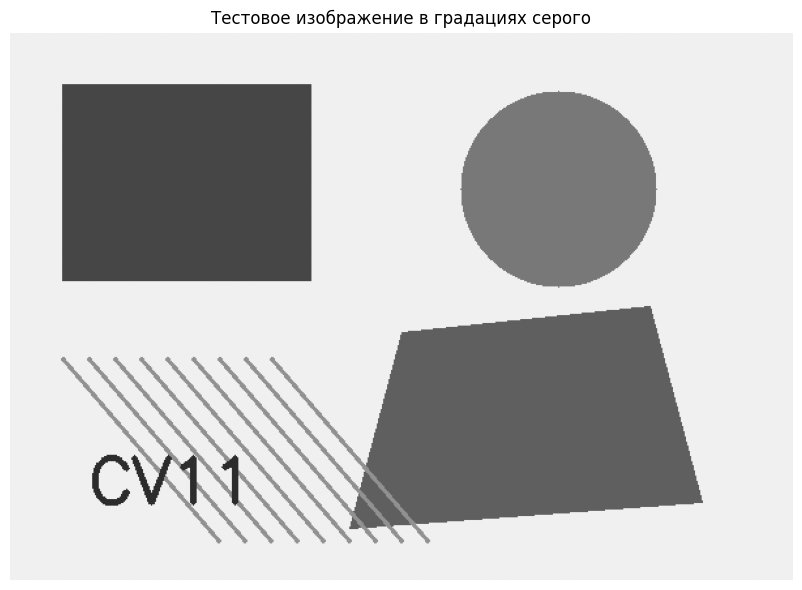

In [3]:
plt.figure(figsize=(9, 6))
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title('Тестовое изображение в градациях серого')
plt.tight_layout()
plt.show()

## Задание 2

Найти углы методом FAST и отобразить их красным цветом (cv.drawKeypoints).

In [4]:
fast = cv2.FastFeatureDetector_create(threshold=25, nonmaxSuppression=True)
kp_fast = fast.detect(gray, None)
fast_vis = cv2.drawKeypoints(gray, kp_fast, None, color=(0, 0, 255))
print(f'FAST: найдено ключевых точек = {len(kp_fast)}')

FAST: найдено ключевых точек = 24


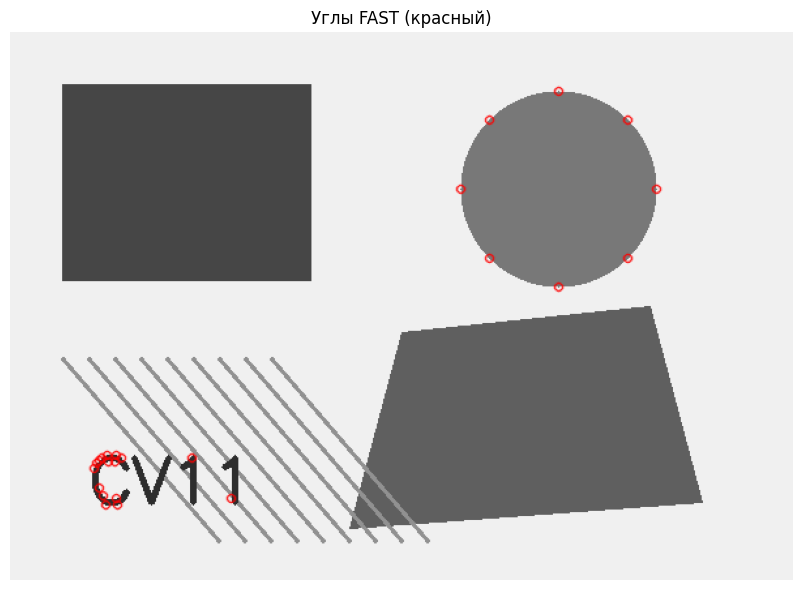

In [5]:
plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(fast_vis, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Углы FAST (красный)')
plt.tight_layout()
plt.show()

## Задание 3

Найти углы методом Харриса (cv.cornerHarris) и отобразить их синим цветом.

In [6]:
gray_f = np.float32(gray)
harris = cv2.cornerHarris(gray_f, blockSize=2, ksize=3, k=0.04)
harris = cv2.dilate(harris, None)
harris_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
mask_harris = harris > 0.01 * harris.max()
harris_vis[mask_harris] = (255, 0, 0)
print(f'Harris: число пикселей-углов = {int(np.count_nonzero(mask_harris))}')

Harris: число пикселей-углов = 3585


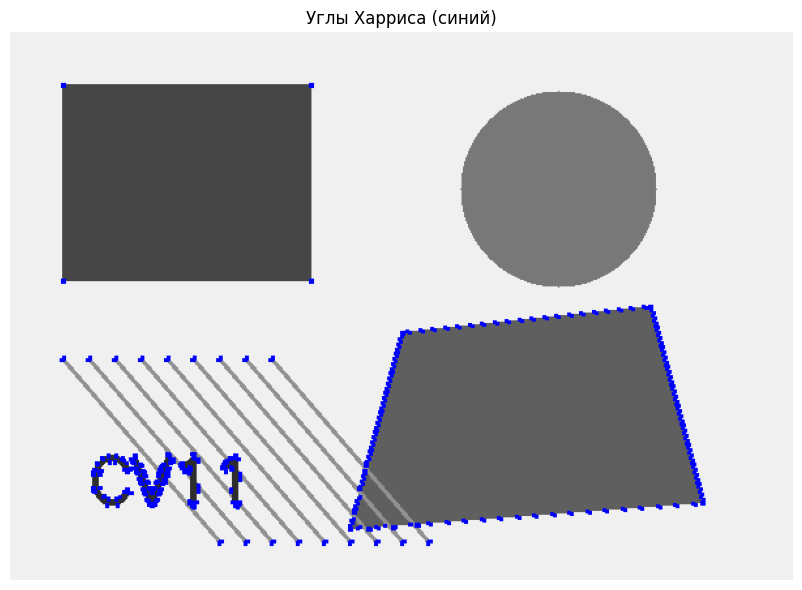

In [7]:
plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(harris_vis, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Углы Харриса (синий)')
plt.tight_layout()
plt.show()

## Задание 4

Найти особые точки и вывести дескрипторы для первых 5 из них, используя ORB (cv.ORB).

In [8]:
orb = cv2.ORB_create(nfeatures=500)
kp_orb, des_orb = orb.detectAndCompute(gray, None)
orb_vis = cv2.drawKeypoints(gray, kp_orb, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
print(f'ORB: найдено ключевых точек = {len(kp_orb)}')
if des_orb is None or len(des_orb) == 0:
    print('Дескрипторы ORB не найдены')
else:
    n_show = min(5, len(des_orb))
    print(f'Первые {n_show} дескрипторов ORB:')
    for i in range(n_show):
        print(f'#{i + 1}: {des_orb[i].tolist()}')

ORB: найдено ключевых точек = 373
Первые 5 дескрипторов ORB:
#1: [0, 32, 2, 137, 76, 9, 168, 64, 44, 32, 242, 2, 136, 138, 32, 64, 104, 140, 110, 128, 0, 179, 193, 192, 148, 32, 138, 0, 21, 8, 49, 128]
#2: [2, 0, 70, 137, 76, 11, 232, 72, 191, 32, 210, 2, 204, 138, 48, 64, 122, 141, 127, 129, 0, 179, 67, 208, 20, 32, 139, 128, 21, 8, 113, 128]
#3: [2, 0, 70, 137, 76, 11, 232, 72, 191, 32, 210, 2, 204, 138, 48, 64, 122, 141, 127, 129, 0, 179, 67, 208, 20, 32, 139, 128, 21, 8, 113, 128]
#4: [0, 32, 2, 137, 76, 9, 168, 64, 44, 32, 242, 2, 136, 138, 32, 64, 104, 140, 110, 128, 0, 179, 193, 192, 148, 32, 138, 0, 21, 8, 49, 128]
#5: [0, 32, 2, 137, 76, 9, 168, 64, 44, 32, 242, 2, 136, 138, 32, 64, 104, 140, 110, 128, 0, 179, 193, 192, 148, 32, 138, 0, 21, 8, 49, 128]


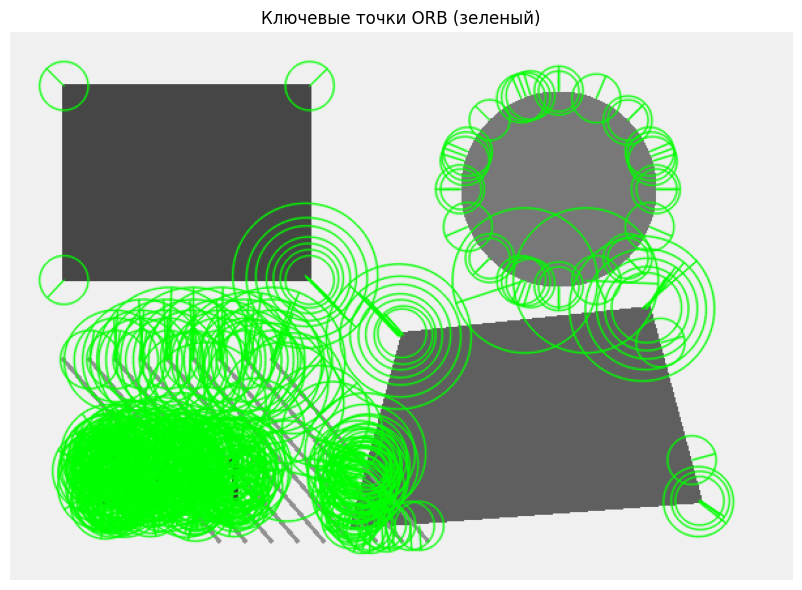

In [9]:
plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(orb_vis, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Ключевые точки ORB (зеленый)')
plt.tight_layout()
plt.show()

### Выполнил: Мелешенко Николай